In [1]:
import sys
sys.path.append('../src/training-on-CM2.6')
import xarray as xr
import xgcm

import warnings
warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
    message=".*Dataset.dims.*"
)

from helpers.plot_helpers import *
from helpers.selectors import *

%load_ext autoreload
%autoreload 3

In [2]:
def read_dataset(key='train'):
    base_path = '/scratch/zanna/data/cm2.6-Perezhogin-etal-2025/factor-4'
    
    # Read file with grid information
    depth_selector = lambda x: x.isel(zl=np.arange(0,50,5)) if len(x.zl)==50 else x
    static = depth_selector(xr.open_dataset(f'{base_path}/param.nc'))
    
    # Read permanent features
    permanent_features = xr.open_dataset(f'{base_path}/permanent_features.nc').load()
    
    # Read time-dependent data
    data = xr.open_mfdataset(f'{base_path}/{key}*.nc', chunks={'time':1}, concat_dim='time', combine='nested').sortby('time')

    # Merge permanent and time-depending datasets
    data = xr.merge([data, permanent_features])

    # xgcm grid
    grid = xgcm.Grid(static, coords={
                'X': {'center': 'xh', 'right': 'xq'},
                'Y': {'center': 'yh', 'right': 'yq'}
            },
            boundary={"X": 'periodic', 'Y': 'fill'},
            fill_value = {'Y':0})

    return data, static, grid

data, param, grid = read_dataset()

In [3]:
default_indices_names = ["i", "j", "k", "m", "n", "l", "o", "s", "t", "p", "q", "r", "a", "b"]

def transpose_data(array):
    '''
    Note transposing does not relabel data
    but simply changes its representation in xarray
    Thus, it is safe to be used everywhere
    without affecting math
    '''
    dims = []
    for dim in ['time', 'zl', 'yh', 'xh']:
        if dim in array.dims:
            dims.append(dim)
    dims.append(...)
    for dim in default_indices_names:
        if dim in array.dims:
            dims.append(dim)
    return array.transpose(*dims)

def ddx(array):
    '''
    d/dx operator applied in center points
    '''
    out = param.wet * grid.interp(param.wet_u * grid.diff(param.wet * array,'X') / param.dxCu, 'X')
    return transpose_data(out)
def ddy(array):
    '''
    d/dy operator applied in center points
    '''
    out = param.wet * grid.interp(param.wet_v * grid.diff(param.wet * array,'Y') / param.dyCv, 'Y')
    return transpose_data(out)

# Constructing basis of velocity gradients, hessians, and so on

In [4]:
def pair_is_equal(pair1, pair2, symmetric_indices_sets):
    '''
    Service two function which decides if
    contraction of pair1 of indices and over pair2
    is identical given the symmetry of the tensor
    symmetric_indices_sets = list(list())
    '''
    if set(pair1) == set(pair2):
        return True

    # This operator returns a full list of entries which
    # are different in two sets. In a case of symmetric 
    # tensors these should be two elements and
    # both should lie in symmetric_indices_set
    different_indices = list(set(pair1) ^ set(pair2))
    
    # We check each set indipendently
    # if different indices correspond to any of sets
    # then the pairs are equal
    for symmetric_indices in symmetric_indices_sets:
        idx_in_symmetric_set = [False] * len(different_indices)
        for j, idx in enumerate(different_indices):
            if idx in symmetric_indices:
                idx_in_symmetric_set[j] = True
        if all(idx_in_symmetric_set):
            return True
    return False

In [5]:
import itertools
import copy
class Tensor():
    def __init__(self, array, label='', symmetric_indices_sets=[]):
        '''
        array is xarray
        label is the Latex code describing the 
        tensor. letters describing default indices
        should not be used in other sense
        all tensor indices present in array must
        be specified in label as well
        '''
        self.array = transpose_data(array)
        self.verbose = False
        self.label = label
        # All tuples of indices which show symmetry of the tensor
        # for example d3 u / dx_i dx_j dx_k is symmetric in indices
        # i,j,k and thus should pass a tuple ('i', 'j', 'k')
        # Temporarily, this set is should be set directly
        self.symmetric_indices_sets = symmetric_indices_sets
    
    # Service functions
    def _repr_latex_(self):
        '''
        Print tensor latex equation
        '''
        if self.label:
            return f"${self.label}$".replace("@", "\\partial")
        else:
            return f"$T({', '.join(self.dims())})$"

    def rename(self):
        '''
        Rename indices to the default set.
        Useful after contraction.
        Modifies both array and label
        '''
        label = self.label
        for idx_old, idx_new in zip(self.dims(), default_indices_names):
            self.array = self.array.rename({idx_old:idx_new})
            label = label.replace(idx_old, idx_new)
        return Tensor(self.array, label)

    def dims(self):
        '''
        Returns list of tensor indices
        '''
        return [idx for idx in self.array.dims if idx in default_indices_names]

    def copy(self):
        '''
        Copy tensor object and associated data
        '''
        return Tensor(self.array.copy(), self.label, copy.deepcopy(self.symmetric_indices_sets))

    def contract_to_rank(self, rank=1):
        """
        Recursively contract tensor indices until it has the desired rank.
        Returns a list of Tensor objects of the target rank.
        """
        n = len(self.dims())

        # Base case: impossible
        if n <= rank or (n - rank) % 2 != 0:
            return []

        # Base case: one contraction left
        if n - rank == 2:
            return self.list_of_all_contractions()

        # Recursive case
        results = []
        for contracted in self.list_of_all_contractions():
            results.extend(contracted.contract_to_rank(rank=rank))
        
        return results

    def list_of_all_contractions(self):
        '''
        Takes the current tensor and if its
        rank is higher or equal than 2,
        finds all possible contractions over
        two indices filtering out identical
        ones given by symmetry of the tensor
        '''

        if len(self.dims()) < 2:
            return []

        # All unordered combinations
        pairs = [pair for pair in itertools.combinations(self.dims(),2)]

        # Keep only pairs which remain after applying symmetry conditions
        pairs_filtered = []

        for pair1 in pairs:
            append = True
            for pair2 in pairs_filtered:
                if pair_is_equal(pair1, pair2, self.symmetric_indices_sets):
                    append=False
            
            if append:
                pairs_filtered.append(pair1)

        # Compute contractions
        output = []
        for pair in pairs_filtered:
            output.append(self.contract(pair))

        return output

    def contract(self, *pairs):
        out = self
        for pair in pairs:
            out = out._contract(pair)
        return out
    
    def transpose(self, pair):
        '''
        Swap two indices (e.g. transpose over i and j).
        pair: tuple of two indices (e.g. ("i", "j"))
        '''
        # Swap dims in the underlying xarray
        arr_new = self.array.rename({pair[0]: "tmp"}).rename({pair[1]: pair[0]}).rename({"tmp": pair[1]})

        # Update LaTeX label: swap pair[0] and pair[1]
        tmp_symbol = "__TMP__"
        new_label = (
            self.label
            .replace(pair[0], tmp_symbol)
            .replace(pair[1], pair[0])
            .replace(tmp_symbol, pair[1])
        )

        return Tensor(arr_new, new_label)
        
    def _contract(self, pair):
        '''
        Contract tensor over a pair of indices
        By convention, contracted indices are big in the label
        and thus they are not anymore free dimensions of the tensor
        '''
        out = 0
        for i in range(2):
            out += self.array.isel({pair[0]:i, pair[1]:i})
        # pick a single uppercase letter from the pair[0]
        contracted = pair[0].upper()
        # replace both indices in the label with the uppercase one
        new_label = self.label.replace(pair[0], contracted).replace(pair[1], contracted)
        return Tensor(transpose_data(out), new_label)

    def __add__(self, _tensor2):
        return Tensor(self.array+_tensor2.array, self.label+'+'+_tensor2.label)

    def __sub__(self, _tensor2):
        return Tensor(self.array-_tensor2.array, self.label+'-'+_tensor2.label)

    def __mul__(self, _tensor2):
        '''
        Multiplies two tensors as outer product,
        i.e. without repeating indices
        Main code handles that indices are indeed not reepeting
        '''
        tensor2 = _tensor2.copy()

        idx_set1 = self.dims()
        idx_set2 = tensor2.dims()

        # We rename indices of the second tensor
        idx_rename = [idx for idx in idx_set2 if idx in idx_set1]

        # Empty set of indices not yet used in these tensor
        idx_empty = [idx for idx in default_indices_names if idx not in idx_set1 and idx not in idx_set2]
        
        label2 = tensor2.label
        symmetric_indices_sets2 = tensor2.symmetric_indices_sets
        for i,j in zip(idx_rename, idx_empty):
            tensor2.array = tensor2.array.rename({i:j})
            label2 = label2.replace(i, j)
            symmetric_indices_sets2 = [[s.replace(i, j) for s in sub] for sub in symmetric_indices_sets2]
        
        label1 = f'({self.label})'
        label2 = f'({label2})'

        out = self.array * tensor2.array
        if self.verbose:
            print('Final set of indices', [idx for idx in out.dims if idx in default_indices_names])
            
        return Tensor(out, label1+label2,self.symmetric_indices_sets+symmetric_indices_sets2)

    def diff(self):
        '''
        Differentiate current tensor by applying \partial operator
        and increasing tensor rank by one
        '''
        idx_empty = [idx for idx in default_indices_names if idx not in self.dims()]
        new_index = idx_empty[0]

        # @ is a special symbol representing \\partial
        label = f'@_{new_index}' + self.label
        return Tensor(xr.concat([ddx(self.array), ddy(self.array)], dim=new_index), label=label)

    @classmethod
    def init_vector(cls, u, v, label="u_i"):
        """
        Construct a rank-1 vector Tensor from two components u, v.
        Concatenates along a new index 'i'.
        """
        arr = xr.concat([u, v], dim='i')
        return cls(arr, label=label)

In [6]:
derivatives = {}
derivatives['D0'] = Tensor.init_vector(data.u_h, data.v_h, label="u_i")
derivatives['D1'] = derivatives['D0'].diff()
derivatives['D2'] = derivatives['D1'].diff()
derivatives['D3'] = derivatives['D2'].diff()
derivatives['D4'] = derivatives['D3'].diff()

# Manually set symmetric tensors

In [7]:
derivatives['D2'].symmetric_indices_sets = [['j','k']]
derivatives['D3'].symmetric_indices_sets = [['j','k', 'm']]
derivatives['D4'].symmetric_indices_sets = [['j','k', 'm', 'n']]

# Not recursive contraction

In [9]:
from IPython.display import Math, display

for DD in ['D1', 'D2', 'D3', 'D4']:
    for t in derivatives[DD].list_of_all_contractions():
        display(Math(f"{t._repr_latex_()}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [93]:
for t in (derivatives['D1'] * derivatives['D0']).list_of_all_contractions():
    display(Math(f"{t.rename()._repr_latex_()}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [94]:
for t in (derivatives['D2'] * derivatives['D0']).list_of_all_contractions():
    display(Math(f"{t.rename()._repr_latex_()}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [95]:
for t in (derivatives['D2'] * derivatives['D1']).list_of_all_contractions():
    display(Math(f"{t.rename()._repr_latex_()}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Symmetric indices

In [97]:
tensor = derivatives['D2'] * derivatives['D1']
display(Math(f"{tensor._repr_latex_()}"))
(tensor).symmetric_indices_sets

<IPython.core.display.Math object>

[['j', 'k']]

In [98]:
tensor = derivatives['D1'] * derivatives['D2']
display(Math(f"{tensor._repr_latex_()}"))
(tensor).symmetric_indices_sets

<IPython.core.display.Math object>

[['n', 'k']]

In [99]:
tensor = derivatives['D2'] * derivatives['D2']
display(Math(f"{tensor._repr_latex_()}"))
(tensor).symmetric_indices_sets

<IPython.core.display.Math object>

[['j', 'k'], ['n', 'l']]

In [101]:
tensor = derivatives['D4'] * derivatives['D3']
display(Math(f"{tensor._repr_latex_()}"))
(tensor).symmetric_indices_sets

/ext3/miniconda3/lib/python3.11/site-packages/dask/array/core.py:4996: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(


<IPython.core.display.Math object>

[['j', 'k', 'm', 'n'], ['o', 's', 't']]

In [102]:
tensor = derivatives['D3'] * derivatives['D4']
display(Math(f"{tensor._repr_latex_()}"))
(tensor).symmetric_indices_sets

/ext3/miniconda3/lib/python3.11/site-packages/dask/array/core.py:4996: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(


<IPython.core.display.Math object>

[['j', 'k', 'm'], ['o', 's', 't', 'n']]

In [103]:
for t in (derivatives['D3'] * derivatives['D4']).list_of_all_contractions():
    display(Math(f"{t.rename()._repr_latex_()}"))

/ext3/miniconda3/lib/python3.11/site-packages/dask/array/core.py:4996: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Recursive contractions

In [10]:
for t in (derivatives['D1'] * derivatives['D0']).list_of_all_contractions():
    display(Math(f"{t.rename()._repr_latex_()}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [20]:
for t in (derivatives['D1'] * derivatives['D0']).contract_to_rank(rank=1):
    display(Math(f"{t.rename()._repr_latex_()}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [25]:
for t in (derivatives['D0']).contract_to_rank(rank=1):
    display(Math(f"{t.rename()._repr_latex_()}"))

In [28]:
for t in (derivatives['D2']).contract_to_rank(rank=1):
    display(Math(f"{t.rename()._repr_latex_()}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [29]:
for t in (derivatives['D3']).contract_to_rank(rank=1):
    display(Math(f"{t.rename()._repr_latex_()}"))

In [33]:
derivatives['D4']

In [30]:
for t in (derivatives['D4']).contract_to_rank(rank=1):
    display(Math(f"{t.rename()._repr_latex_()}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

# Strain rate

In [80]:
strain_rate = (derivatives['D1'] + derivatives['D1'].transpose(['i', 'j']))
strain = (strain_rate * strain_rate).contract(['m', 'j'], ['i', 'k'])

strain

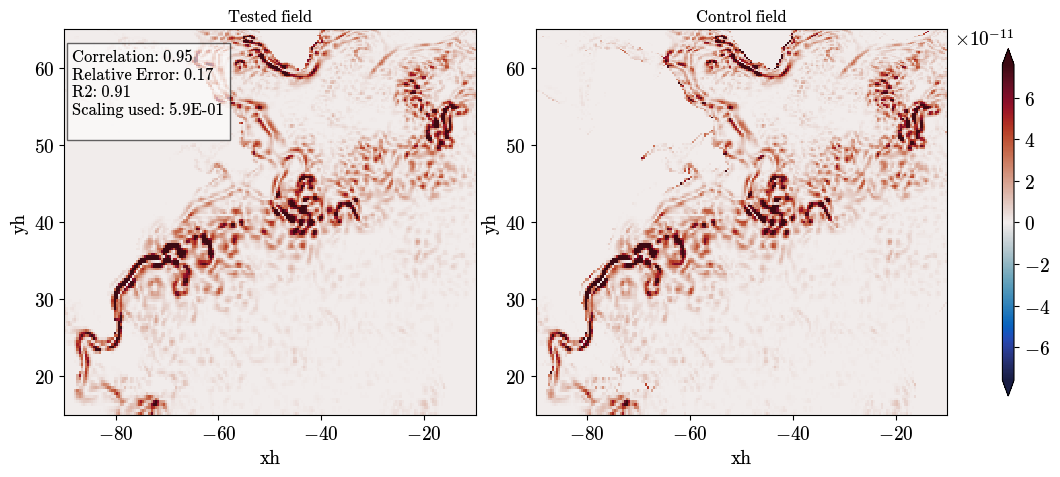

In [81]:
compare(strain.array[0][0], data.shear_mag[0][0]**2, scale=True);

In [82]:
derivatives['D2']

In [83]:
derivatives['D1'].contract(['i', 'j'])

In [84]:
(derivatives['D1'] * derivatives['D2']).contract(['i', 'j']).contract(['k','n'])

In [85]:
(derivatives['D1'] * derivatives['D2']).contract(['i', 'j'], ['k', 'n'])

# Set of all possible gradient models of second order

In [86]:
tensor_D1_D2 =  derivatives['D2'] * derivatives['D1']

In [87]:
indices = tensor_D1_D2.dims()
print(indices)

['i', 'j', 'k', 'm', 'n']


In [48]:
def quad_to_two_pairs(quad):
    """
    Given a 4-tuple of indices, return all unordered splits into two pairs.
    
    Each output element is ((pair1), (pair2)), unordered within each pair
    and unordered between pairs.
    """
    result = []
    for first_pair in combinations(quad, 2):
        # Remaining two indices automatically form the second pair
        second_pair = tuple(idx for idx in quad if idx not in first_pair)
        # Sort within each pair
        pair1 = tuple(sorted(first_pair))
        pair2 = tuple(sorted(second_pair))
        # Sort the pairs themselves to avoid duplicates (unordered)
        result.append(tuple(sorted([pair1, pair2])))
    
    # Remove duplicates
    result = list(set(result))
    return result

In [49]:
from itertools import combinations
# Step 1: all unordered 4-tuples
four_tuples = list(combinations(indices, 4))
#print(four_tuples)
# Step 2: for each 4-tuple, get all unordered pairs
for quad in four_tuples:
    pairs = quad_to_two_pairs(quad)

    for p in pairs:
        print(p)

(('i', 'k'), ('j', 'm'))
(('i', 'j'), ('k', 'm'))
(('i', 'm'), ('j', 'k'))
(('i', 'k'), ('j', 'n'))
(('i', 'n'), ('j', 'k'))
(('i', 'j'), ('k', 'n'))
(('i', 'm'), ('j', 'n'))
(('i', 'n'), ('j', 'm'))
(('i', 'j'), ('m', 'n'))
(('i', 'n'), ('k', 'm'))
(('i', 'k'), ('m', 'n'))
(('i', 'm'), ('k', 'n'))
(('j', 'm'), ('k', 'n'))
(('j', 'n'), ('k', 'm'))
(('j', 'k'), ('m', 'n'))


# Contract all possible gradient models

In [50]:
NGM2_set = []

# Step 1: all unordered 4-tuples
four_tuples = list(combinations(tensor_D1_D2.dims(), 4))
#print(four_tuples)
# Step 2: for each 4-tuple, get all unordered pairs
for quad in four_tuples:
    pairs = quad_to_two_pairs(quad)
    for p in pairs:
        NGM2_set.append(tensor_D1_D2.contract(p[0]).contract(p[1]).rename())

In [51]:
len(NGM2_set)

15

In [52]:
NGM2_set[1]

In [53]:
NGM2_set[-2]

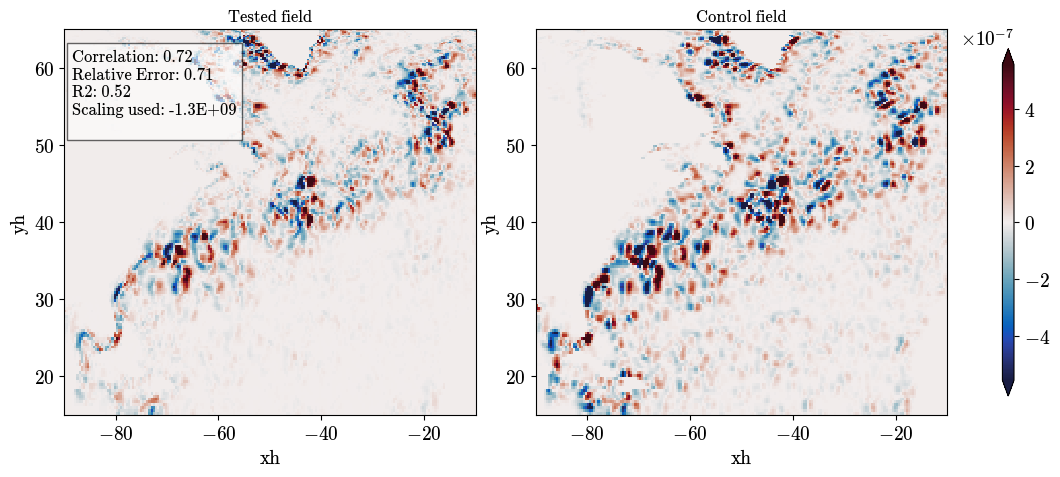

In [58]:
compare((NGM2_set[-2] + NGM2_set[1]).array[0][0].isel(i=0), data.SGSx_h[0][0], scale=True);

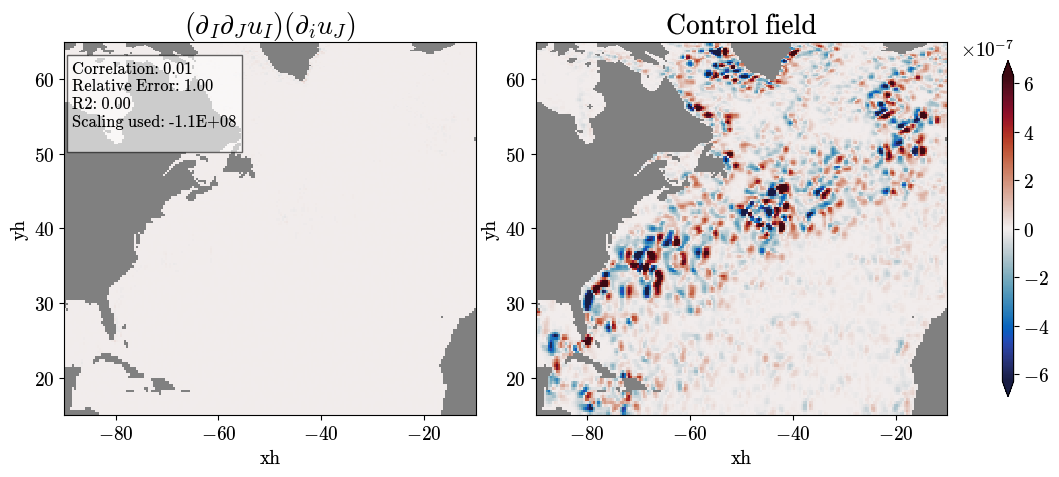

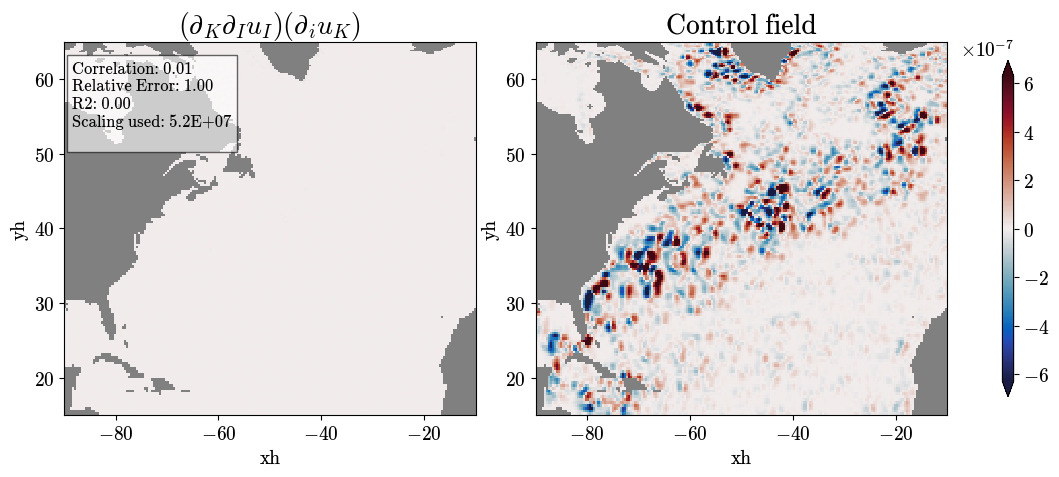

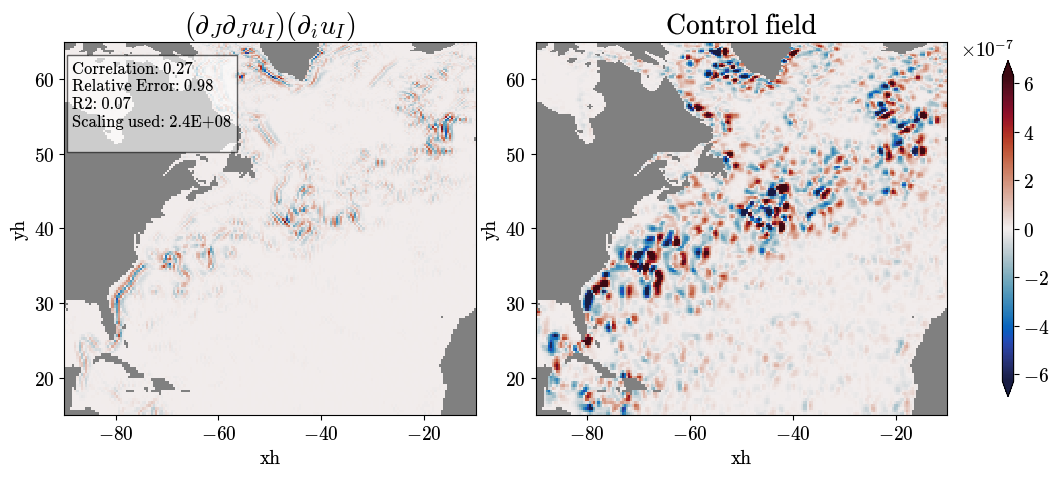

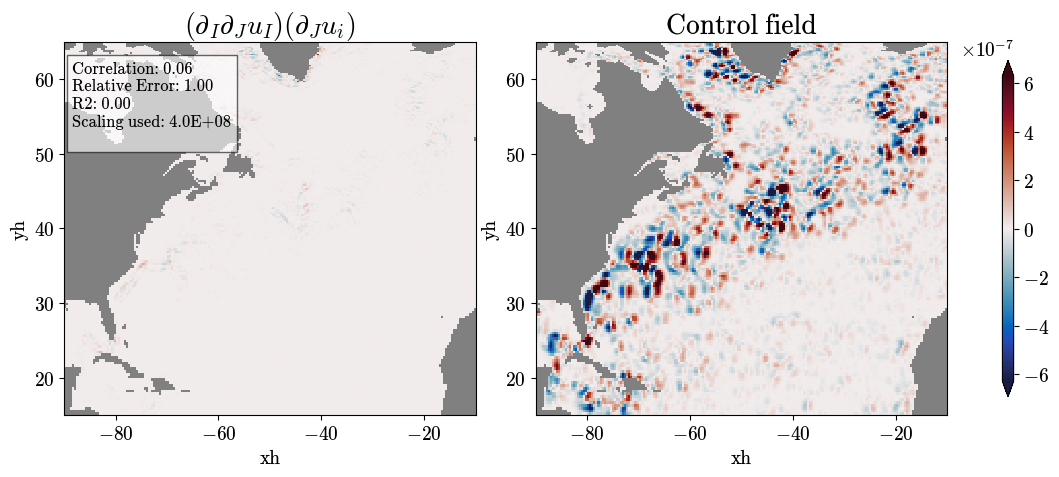

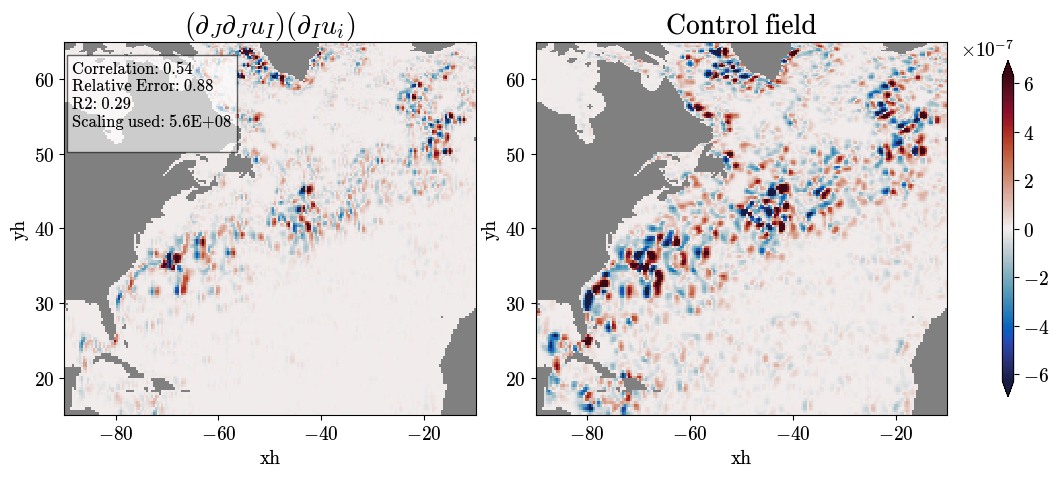

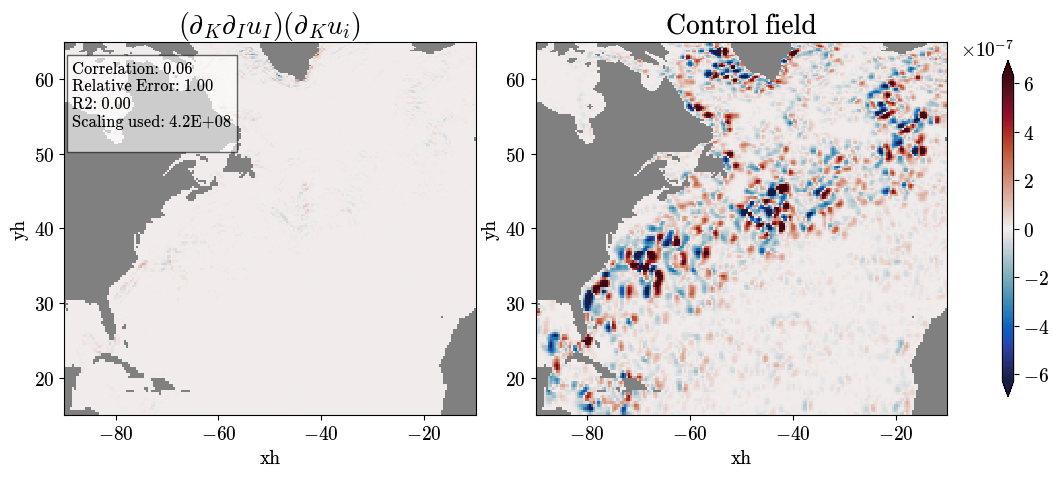

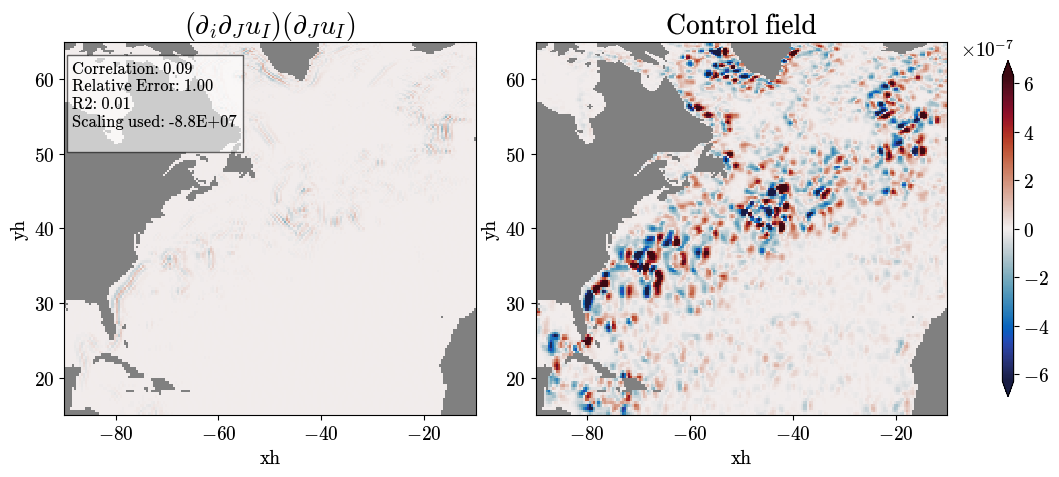

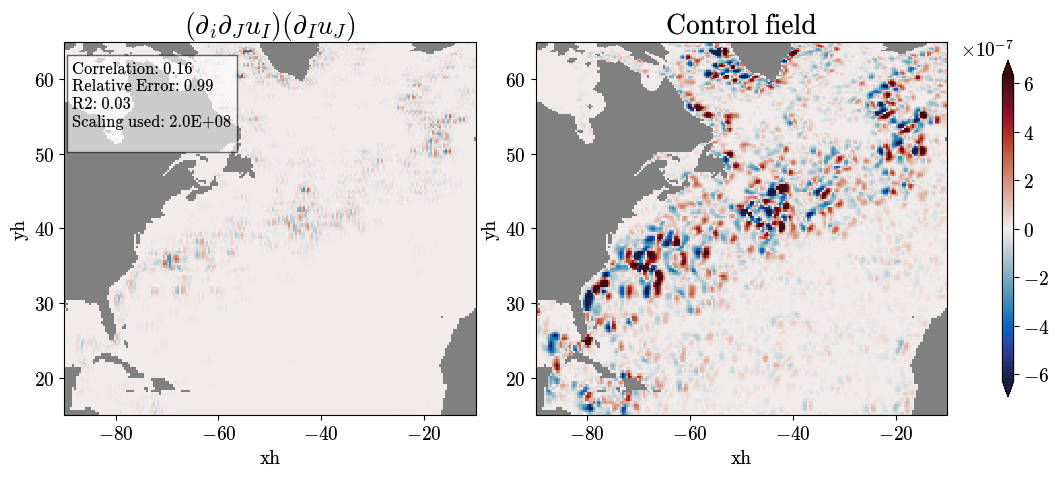

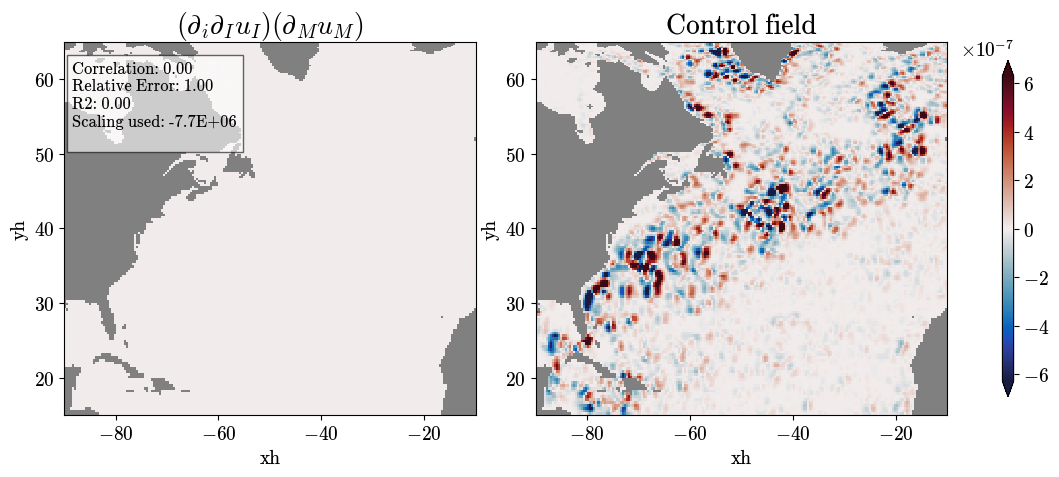

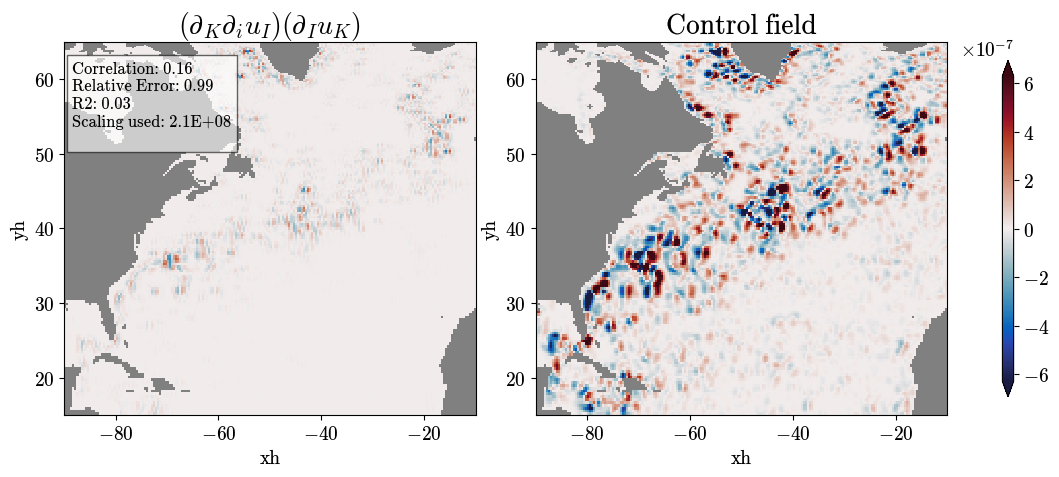

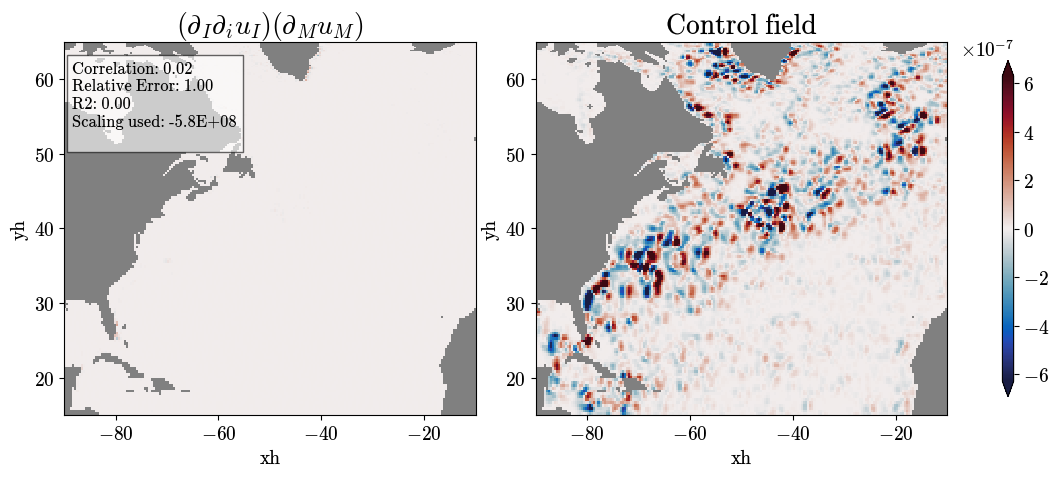

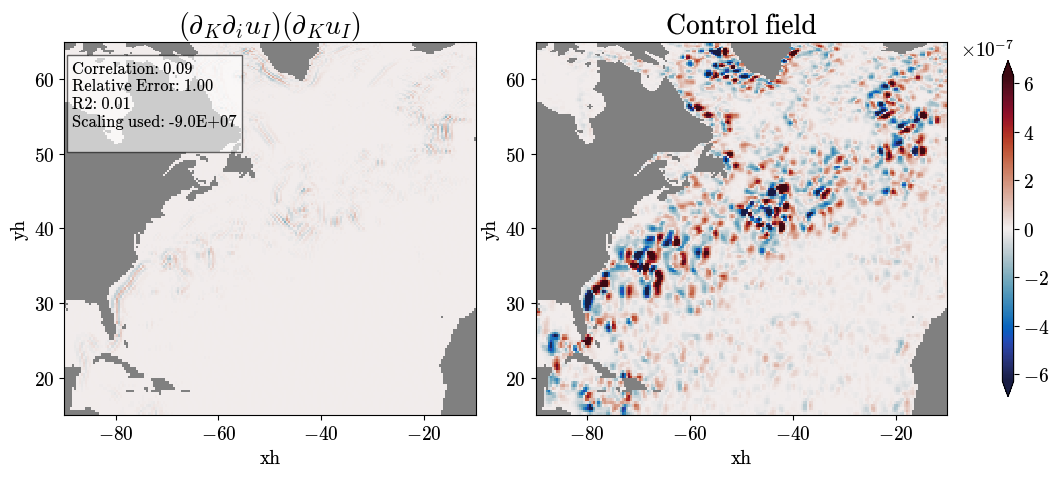

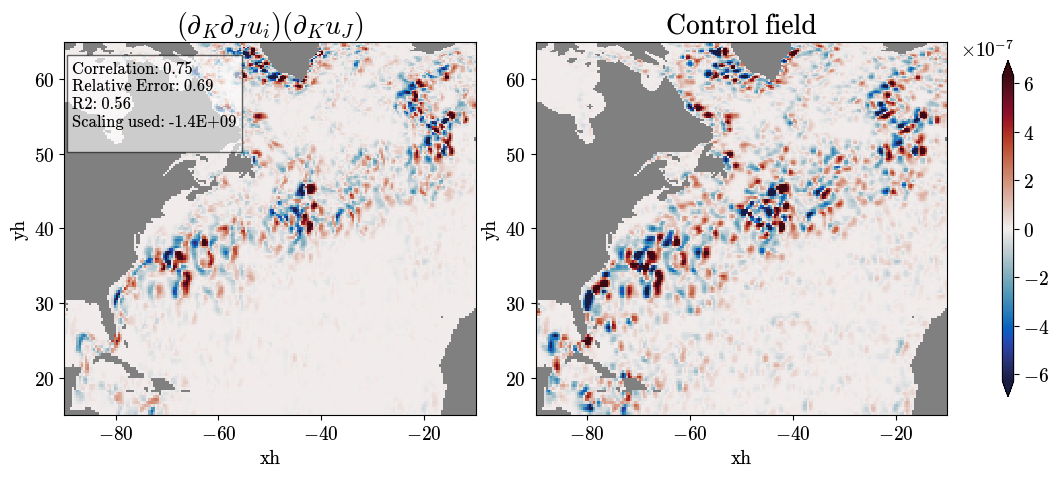

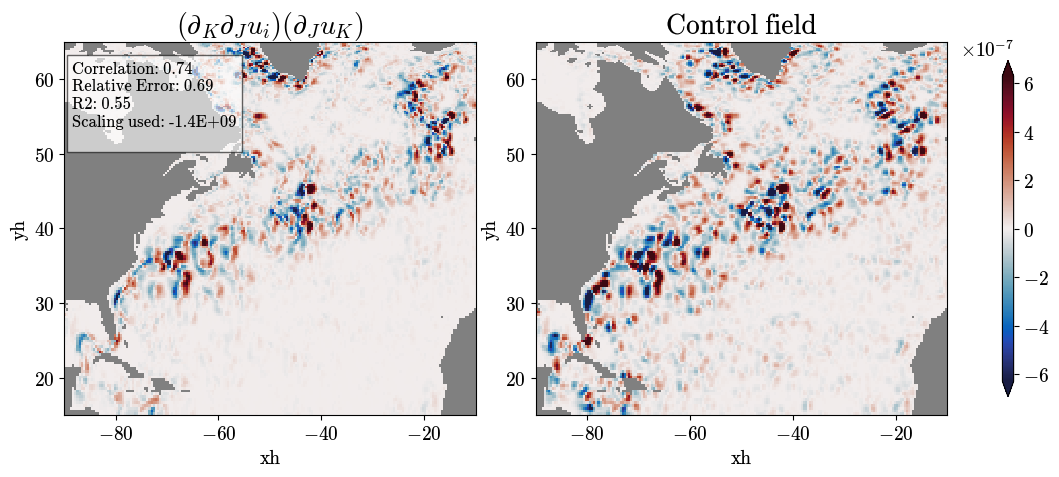

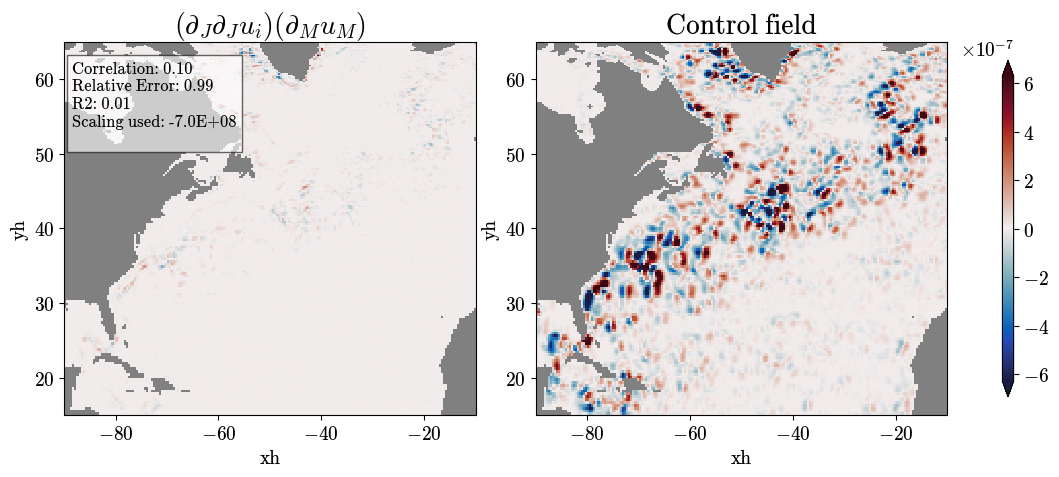

In [54]:
default_rcParams({'font.size':14})
mask = data.wet_nan[0]
for NGM2 in NGM2_set:
    compare(mask * NGM2.array[0][0].isel(i=0), mask * data.SGSx_h[0][0], scale=True, label_test=NGM2._repr_latex_(), fontsize=20)